In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, auc
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV
from scipy.stats.qmc import LatinHypercube
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
import h3
from sklearn.base import clone
from itertools import product
import copy
from sklearn.metrics import f1_score
from sklearn.ensemble import StackingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from collections import ChainMap
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import branca.colormap as cm
import folium
import shap
import joblib
from branca.colormap import LinearColormap

In [2]:
def calculate_confusion_stats(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return tp, tn, fp, fn
    
def micro_averaged_metrics(y_true, y_pred):
    tp, tn, fp, fn = calculate_confusion_stats(y_true, y_pred)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    return precision, recall, f1, tp, tn, fp, fn
    
def calculate_auc_stats(y_true, y_proba):
    thresholds = np.linspace(0, 1, 101)
    tpr_list = []
    fpr_list = []
    
    for thresh in thresholds:
        y_pred = (y_proba >= thresh).astype(int)
        tp, tn, fp, fn = calculate_confusion_stats(y_true, y_pred)
        
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        
        tpr_list.append(tpr)
        fpr_list.append(fpr)
    return np.array(tpr_list), np.array(fpr_list)
    
def plot_roc_curve(fpr, tpr):
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, 
             label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()
    
def plot_confusion_matrix(
    TP,
    FP,
    FN,
    TN,
    process_name
):
    conf_matrix = [[TP, FP],
               [FN, TN]]
    
    print(f'{process_name}:')
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, 
                annot=True, 
                fmt='d', 
                cmap='Blues',
                xticklabels=['Верные(1)', 'Ложные(0)'],
                yticklabels=['Верные(1)', 'Ложные(0)'])
    plt.xlabel('Истинный класс')
    plt.ylabel('Прдесказанный класс')
    plt.show()
    
    precision = TP / (TP + FP)
    recall = TP / (TP + FN)
    accuracy = (TP + TN) / (TP + TN + FP + FN)
    f1 = 2 * (precision * recall) / (precision + recall)
    
    print(f'Точность: {precision:.3f}')
    print(f'Полнота: {recall:.3f}')
    print(f'Правильность (Accuracy): {accuracy:.3f}')
    print(f'F1-метрика: {f1:.3f}')
    
def get_report(y_true, y_pred, y_proba, process_name='Москва, полный датасет',):
    precision, recall, f1, tp, tn, fp, fn = micro_averaged_metrics(y_true, y_pred)
    tpr, fpr = calculate_auc_stats(y_true, y_proba)
    plot_confusion_matrix(tp, fp, fn, tn, process_name)
    plot_roc_curve(fpr, tpr)

In [3]:
def evaluate_model(
    model,
    X_test,
    y_test,
    h3_indices_test,
    process_name='Москва, полный датасет',
):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    print('Результаты полученные на тестовой выборке')
    get_report(y_test, y_pred, y_proba, process_name)
    result_df = X_test.copy()
    result_df['y_true'] = y_test
    result_df['y_proba'] = y_proba
    result_df['h3_index'] = h3_indices_test.copy()
    return result_df

In [4]:
def create_charging_stations_map(result, output_filename):
    colormap = LinearColormap(
        ['red', 'yellow', 'green'],
        vmin=0, vmax=1,
        caption='Вероятность установки (y_proba)'
    )

    avg_location = [55.7522, 37.6156]
    m = folium.Map(location=avg_location, zoom_start=12)

    existing_chargers = folium.FeatureGroup(name="Существующие зарядки")

    for _, row in result.iterrows():
        if pd.notna(row['h3_index']):
            hexagon = row['h3_index']
            proba = row['y_proba']
            
            hex_boundary = h3.cell_to_boundary(hexagon)
            color = colormap(proba)
            
            folium.Polygon(
                locations=hex_boundary,
                color=color,
                fill=True,
                fill_color=color,
                fill_opacity=0.7,
                popup=f"""
                    Вероятность: {proba:.2f}<br>
                    H3 индекс: {hexagon}
                """
            ).add_to(m)
            
            if row['y_true'] == 1:
                center = h3.cell_to_latlng(hexagon)
                folium.Marker(
                    location=center,
                    icon=folium.Icon(color='blue', icon='bolt', prefix='fa'),
                    popup=f"Зарядная станция (H3: {hexagon})"
                ).add_to(existing_chargers)

    existing_chargers.add_to(m)

    folium.GeoJson(
        {
            "type": "FeatureCollection",
            "features": [
                {
                    "type": "Feature",
                    "properties": {},
                    "geometry": {
                        "type": "Polygon",
                        "coordinates": [h3.cell_to_boundary(hex)]
                    }
                } for hex in result['h3_index'] if pd.notna(hex)
            ]
        },
        name="Границы гексагонов",
        style_function=lambda x: {'color': 'black', 'fill': False}
    ).add_to(m)

    colormap.add_to(m)
    folium.LayerControl().add_to(m)

    m.save(output_filename)

In [5]:
# Хочу достать X_train для Лондона
RANDOM_STATE = 42

df = pd.read_csv('/Users/dmitrystarukhin/final_diploma_mipt_sumgf/london/data/final_datasets/london_final_dataset.csv')

relevant_columns = ['bike_amenities', 'children_amenity',
       'food_amenities', 'health_amenity', 'home_amenities',
       'infrastructure_amenities', 'leisure_amenities', 'other_amenities',
       'pet_amenity', 'social_amenities', 'water_amenities', 'parking_area',
       'highway',
       'public_transport', 'voltage',
       'car_amenities', 'needs_amenities', 'shops_amenities',
       'study_amenity', 'work_amenity'
]

X = df[relevant_columns]
y = df['has_charging_station']  # бинарная классификация

idx_0 = np.where(y == 0)[0]
idx_1_with_voltage = np.where((y == 1) & (X['voltage'] > 0))[0]
idx_1_without_voltage = np.where((y == 1) & (X['voltage'] == 0))[0]

n_samples = int(0.7 * min(len(idx_1_with_voltage), len(idx_1_without_voltage), len(idx_0)))

rng = np.random.RandomState(RANDOM_STATE)

train_idx_1_voltage = rng.choice(idx_1_with_voltage, size=n_samples, replace=False)
train_idx_1_no_voltage = rng.choice(idx_1_without_voltage, size=n_samples, replace=False)

test_idx_1_voltage = np.setdiff1d(idx_1_with_voltage, train_idx_1_voltage)
test_idx_1_no_voltage = np.setdiff1d(idx_1_without_voltage, train_idx_1_no_voltage)

test_idx_1 = np.concatenate([test_idx_1_voltage, test_idx_1_no_voltage])
test_idx_0 = rng.choice(idx_0, size=len(test_idx_1), replace=False)

test_idx = np.concatenate([test_idx_1, test_idx_0])
train_idx_full = np.setdiff1d(np.arange(len(y)), test_idx)

X_train_full, X_test = X.iloc[train_idx_full], X.iloc[test_idx]
y_train_full, y_test = y.iloc[train_idx_full], y.iloc[test_idx]

X_train_full_0 = X_train_full[y_train_full == 0]
X_train_full_1 = X_train_full[y_train_full == 1]
y_train_full_0 = y_train_full[y_train_full == 0]
y_train_full_1 = y_train_full[y_train_full == 1]

mean_has_chargers = X_train_full_1.mean(axis=0)

similarities = cosine_similarity(
    X_train_full_0,
    mean_has_chargers.values.reshape(1, -1)
).flatten()
threshold = np.percentile(similarities, 75)

X_train_0_negative = X_train_full_0[similarities >= threshold] #похожие на места с зарядками (ложные нули)
X_train_0_positive = X_train_full_0[similarities < threshold] #непохожие на места с зарядками (реальные нули)
y_train_0_negative  = y_train_full_0[similarities >= threshold] 
y_train_0_positive = y_train_full_0[similarities < threshold] 

X_train_london = pd.concat([X_train_0_positive, X_train_full_1])
y_train = pd.concat([y_train_0_positive, y_train_full_1])

X_full = X.copy()
y_full = y.copy()

In [6]:
df = pd.read_csv('/Users/dmitrystarukhin/final_diploma_mipt_sumgf/moscow/moscow_data/final_datasets/dataset_moscow.csv')

relevant_columns = ['bike_amenities', 'children_amenity',
       'food_amenities', 'health_amenity', 'home_amenities',
       'infrastructure_amenities', 'leisure_amenities', 'other_amenities',
       'pet_amenity', 'social_amenities', 'water_amenities', 'parking_area',
       'highway',
       'public_transport', 'voltage',
       'car_amenities', 'needs_amenities', 'shops_amenities',
       'study_amenity', 'work_amenity'
]

X = df[relevant_columns]
y = df['has_charging_station']  # бинарная классификация
h3_indices = df['h3_index']

Результаты полученные на тестовой выборке
Москва, полный датасет, линейная регрессия:


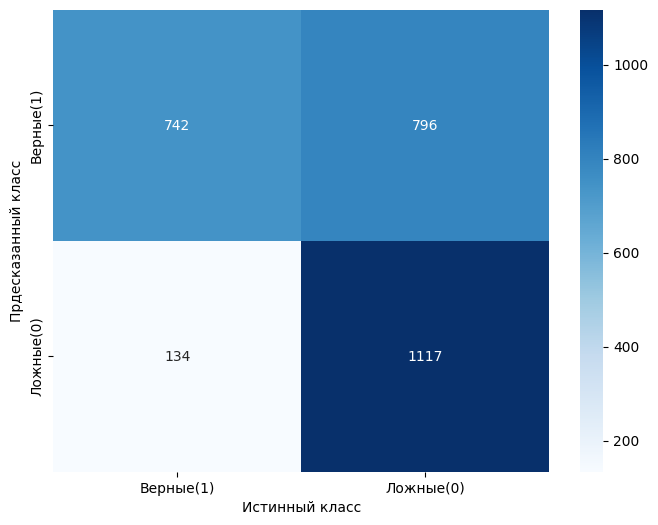

Точность: 0.482
Полнота: 0.847
Правильность (Accuracy): 0.667
F1-метрика: 0.615


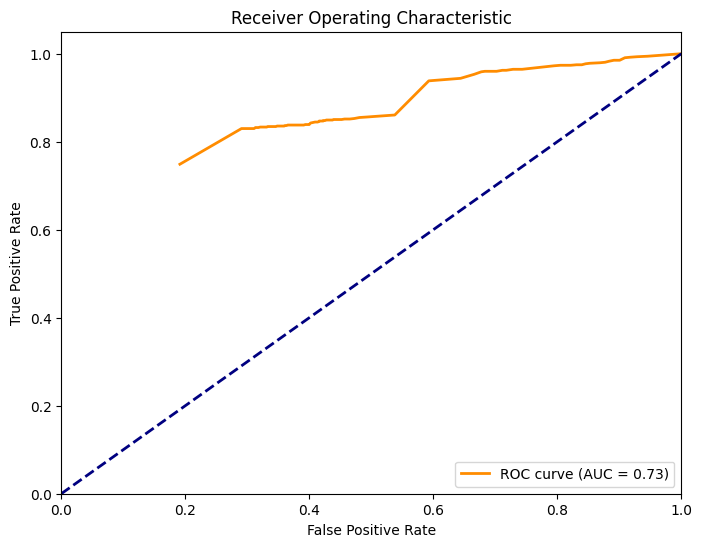

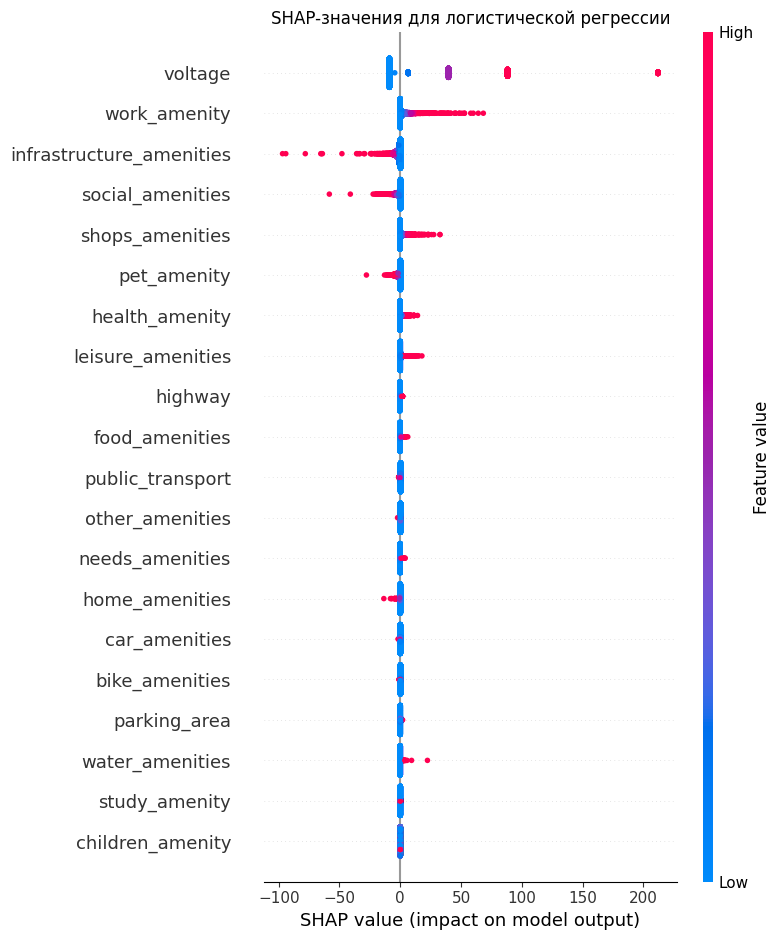

In [7]:
trained_model_lr = joblib.load("/Users/dmitrystarukhin/final_diploma_mipt_sumgf/london/models/logistic_regression.pkl")


result = evaluate_model(
    trained_model_lr,
    X_test=X,
    y_test=y,
    h3_indices_test=h3_indices,
    process_name='Москва, полный датасет, линейная регрессия',
)

explainer = shap.LinearExplainer(trained_model_lr, X_train_london)
shap_values = explainer.shap_values(X)

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, 
    X,  
    feature_names=list(X.columns),  
    show=False
)
plt.title("SHAP-значения для логистической регрессии")
plt.tight_layout()
plt.savefig("/Users/dmitrystarukhin/final_diploma_mipt_sumgf/moscow/statistics/shap_log_reg.pdf", bbox_inches='tight')
plt.show()

create_charging_stations_map(result, '/Users/dmitrystarukhin/final_diploma_mipt_sumgf/moscow/result_map/charging_stations_map_log_reg.html')

Результаты полученные на тестовой выборке
Москва, полный датасет, случайный лес:


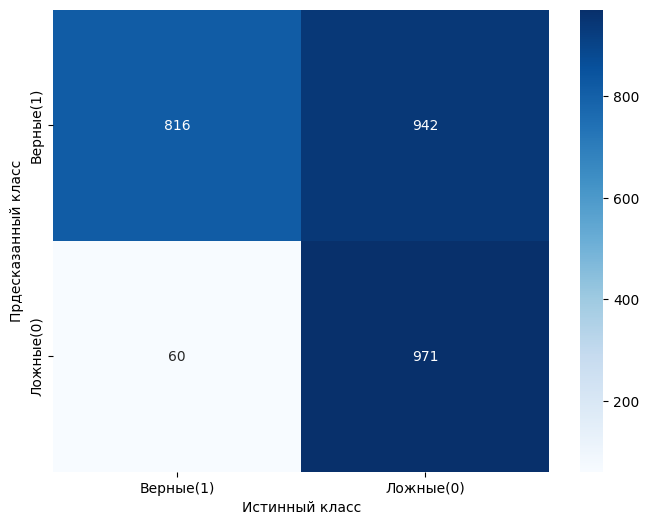

Точность: 0.464
Полнота: 0.932
Правильность (Accuracy): 0.641
F1-метрика: 0.620


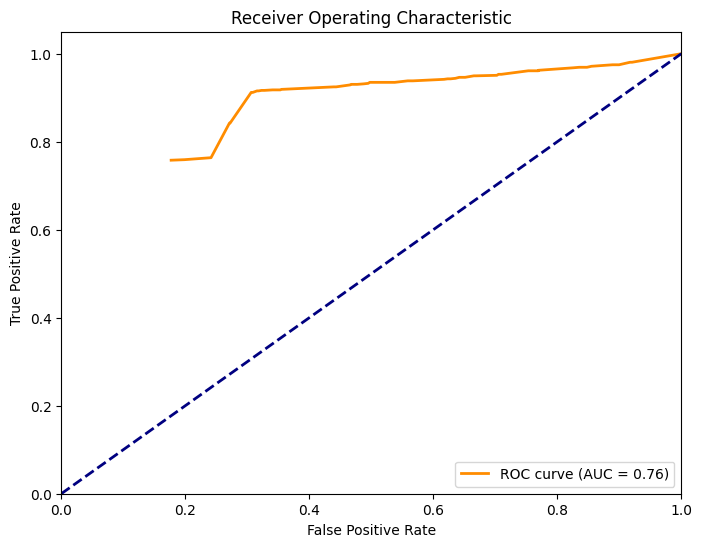

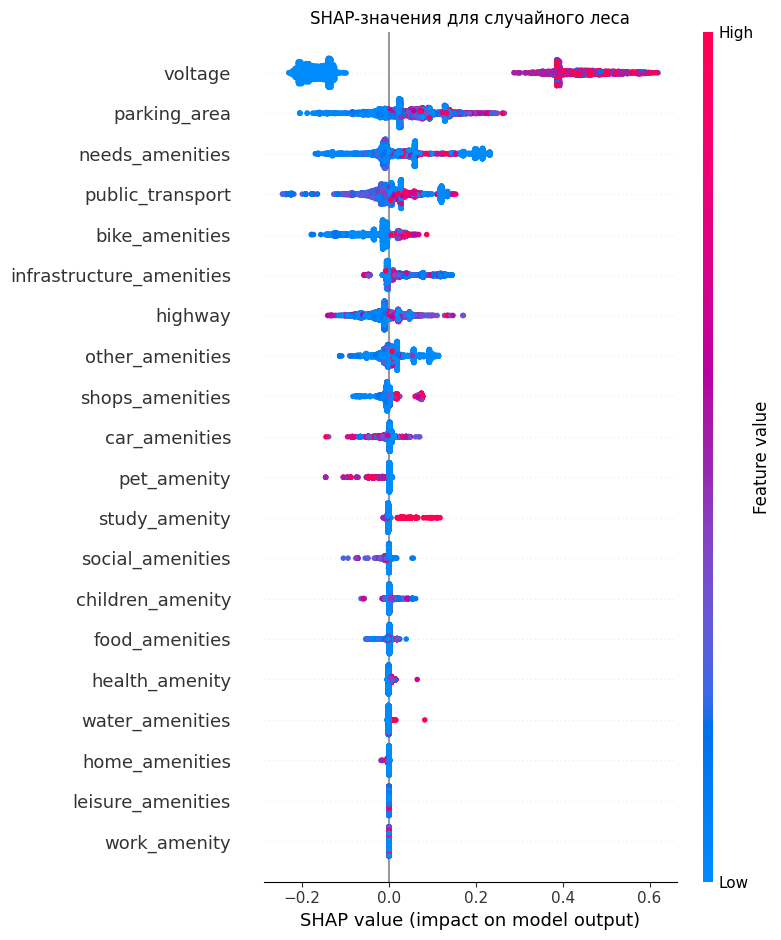

In [8]:
trained_model_rf = joblib.load("/Users/dmitrystarukhin/final_diploma_mipt_sumgf/london/models/random_forest.pkl")


result = evaluate_model(
    trained_model_rf,
    X_test=X,
    y_test=y,
    h3_indices_test=h3_indices,
    process_name='Москва, полный датасет, случайный лес',
)

explainer = shap.TreeExplainer(trained_model_rf)
shap_values = explainer(X)  

plt.figure(figsize=(12, 8))
shap.plots.beeswarm(
    shap_values[:,:,1], 
    max_display=20,
    show=False
)
plt.title("SHAP-значения для случайного леса")
plt.tight_layout()
plt.savefig("/Users/dmitrystarukhin/final_diploma_mipt_sumgf/london/statistics/shap_rf.pdf", bbox_inches='tight')
plt.show()

create_charging_stations_map(result, '/Users/dmitrystarukhin/final_diploma_mipt_sumgf/moscow/result_map/charging_stations_map_rf.html')

Результаты полученные на тестовой выборке
Москва, полный датасет, catboost:


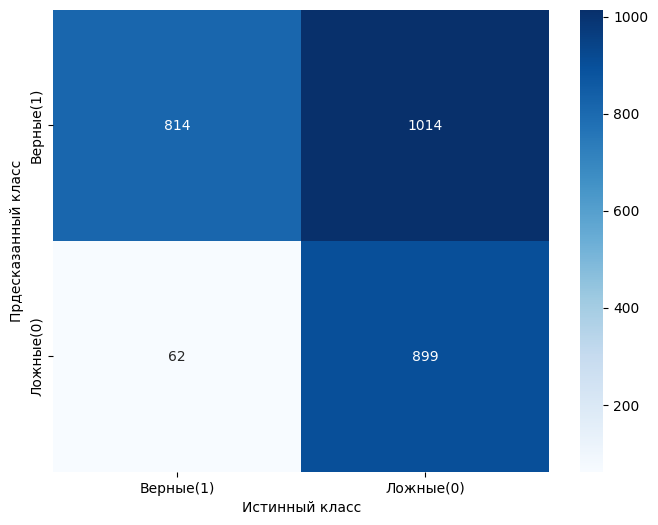

Точность: 0.445
Полнота: 0.929
Правильность (Accuracy): 0.614
F1-метрика: 0.602


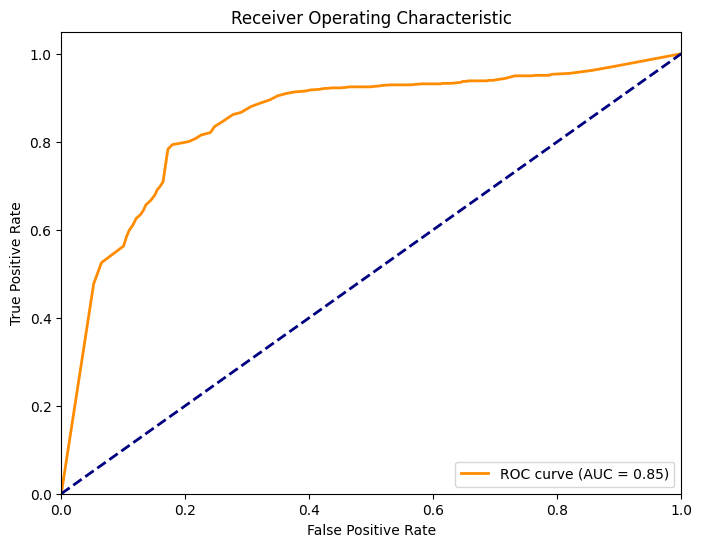

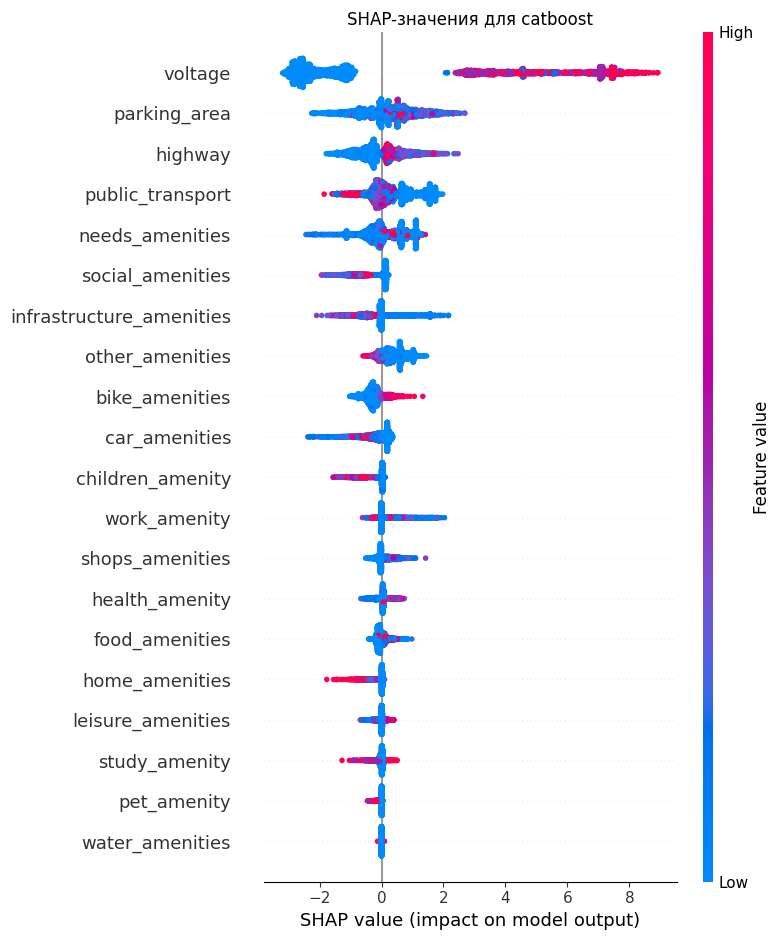

In [9]:
trained_model_cat = joblib.load("/Users/dmitrystarukhin/final_diploma_mipt_sumgf/london/models/catboost.pkl")


result = evaluate_model(
    trained_model_cat,
    X_test=X,
    y_test=y,
    h3_indices_test=h3_indices,
    process_name='Москва, полный датасет, catboost',
)

explainer = shap.TreeExplainer(trained_model_cat)
shap_values = explainer(X)  

plt.figure(figsize=(12, 8))
shap.plots.beeswarm(
    shap_values, 
    max_display=20,
    show=False
)
plt.title("SHAP-значения для catboost")
plt.tight_layout()
plt.savefig("/Users/dmitrystarukhin/final_diploma_mipt_sumgf/london/statistics/shap_cat.pdf", bbox_inches='tight')
plt.show()

create_charging_stations_map(result, '/Users/dmitrystarukhin/final_diploma_mipt_sumgf/moscow/result_map/charging_stations_map_cat.html')

Результаты полученные на тестовой выборке
Москва, полный датасет, xg boost:


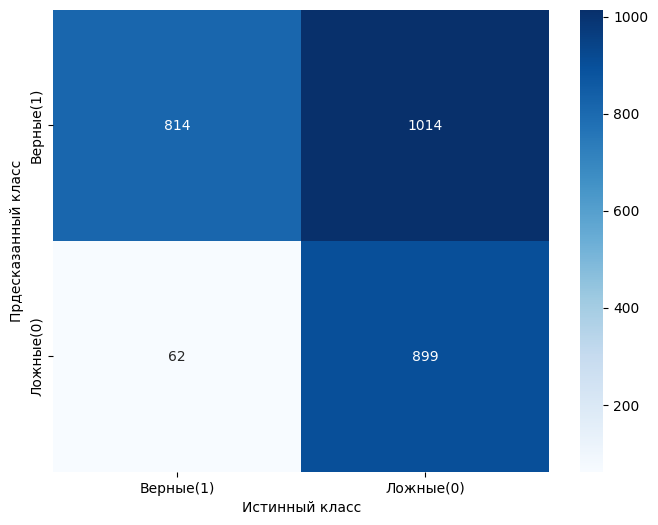

Точность: 0.445
Полнота: 0.929
Правильность (Accuracy): 0.614
F1-метрика: 0.602


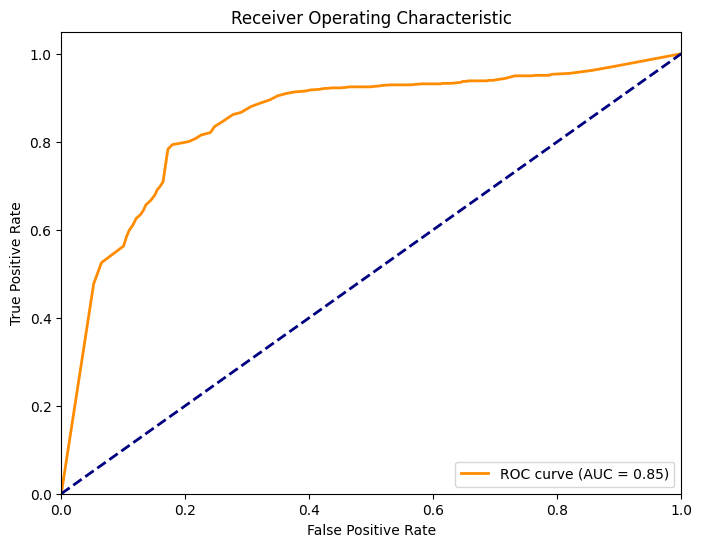

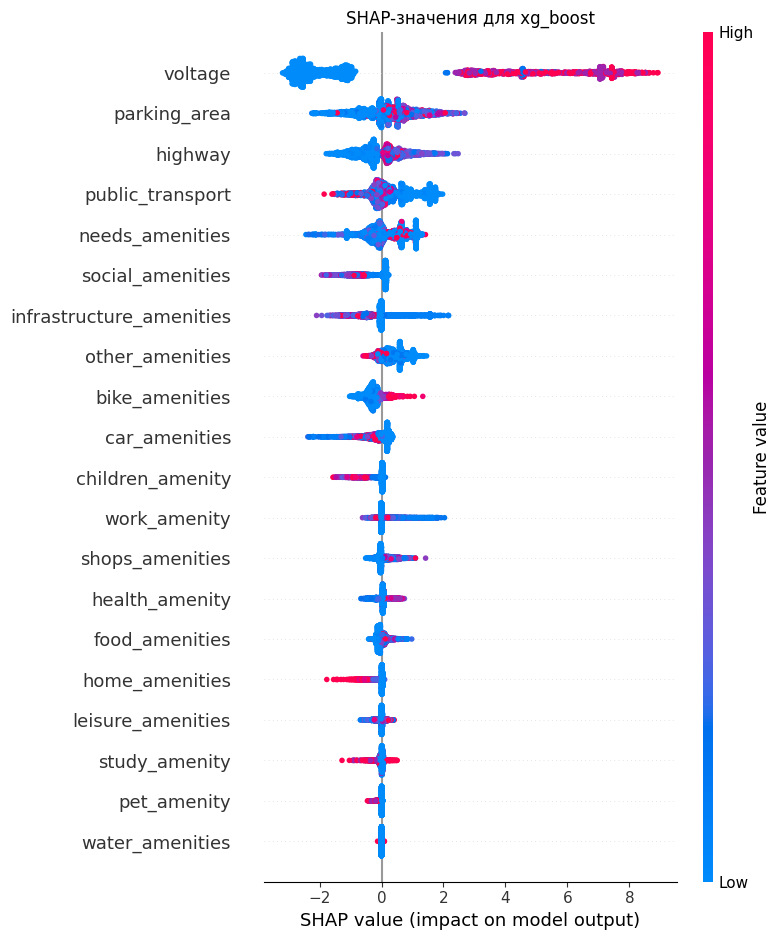

In [10]:
trained_model_xg = joblib.load("/Users/dmitrystarukhin/final_diploma_mipt_sumgf/london/models/catboost.pkl")


result = evaluate_model(
    trained_model_xg,
    X_test=X,
    y_test=y,
    h3_indices_test=h3_indices,
    process_name='Москва, полный датасет, xg boost',
)

explainer = shap.TreeExplainer(trained_model_xg)
shap_values = explainer(X)  

plt.figure(figsize=(12, 8))
shap.plots.beeswarm(
    shap_values, 
    max_display=20,
    show=False
)
plt.title("SHAP-значения для xg_boost")
plt.tight_layout()
plt.savefig("/Users/dmitrystarukhin/final_diploma_mipt_sumgf/london/statistics/shap_xg.pdf", bbox_inches='tight')
plt.show()

create_charging_stations_map(result, '/Users/dmitrystarukhin/final_diploma_mipt_sumgf/moscow/result_map/charging_stations_map_xg.html')